
# MMPR Pipeline prototype
This notebook builds a FAISS index for place recognition, runs localization, apply outliers rejection and select inliers, **merges selected candidate IDs into a mini‑map**, and **aligns the query** against that mini‑map.

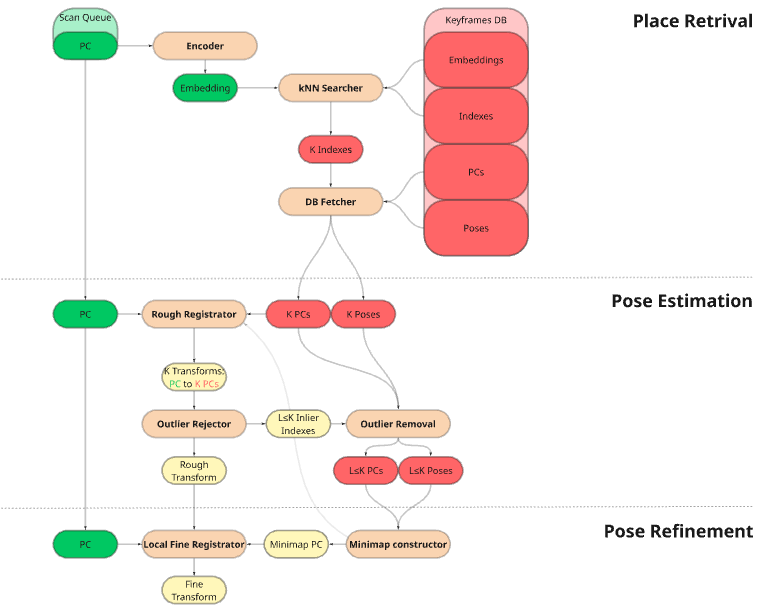

# Import and Metadata

In [1]:

# Standard library
import sys
from pathlib import Path
import logging
import random

# Project src path
sys.path.append("../src")

# Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# MMPR / project-specific imports
from mmpr.modules.inference_index_builder import IndexConfig, InferenceIndexBuilder
from mmpr.modules.utils import get_transformed_scan, build_minimap_from_candidates, align_query, print_pose_refinement_metadata
from mmpr.modules.vis_utils import plot_alignment
from mmpr.modules.ransac_outlier_rejector import RANSACOutlierRejector

# Math / utils
import numpy as np
from tf_math import Transform as Tf
import matplotlib.pyplot as plt
import pypcd4 as pypcd

# ICP for local registration refinement on the mini-map
from icp.cloud_registration import build_local_registration

# We fix the seed to get consistent result
np.random.seed(42)
random.seed(42)

print("Importing all required libs OK!")

2025-10-08 07:45:05,333 - INFO - generated new fontManager
2025-10-08 07:45:07,034 - INFO - Loading faiss with AVX2 support.
2025-10-08 07:45:07,035 - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2025-10-08 07:45:07,036 - INFO - Loading faiss.
2025-10-08 07:45:07,066 - INFO - Successfully loaded faiss.
2025-10-08 07:45:07.072 | WARNING  | opr.models.place_recognition.pointmamba:<module>:16 - The 'pointmamba' package is not installed. Please install it manually if neccessary.


Importing all required libs OK!


In [2]:

# === Paths & Config ===
ROOT_DATA_DIR = Path("/home/docker_mmpr/Datasets/mmpr_dataset")
CONFIG_PATH = "../src/mmpr/configs/default.yaml"

REFERENCE_MAP = "map1/keyframe_map"   # Used to build index / be the DB
QUERY_MAP     = "map2/keyframe_map"   # Source of query scans

reference_map_dir = ROOT_DATA_DIR / REFERENCE_MAP
query_map_dir     = ROOT_DATA_DIR / QUERY_MAP

assert reference_map_dir.exists(), f"Reference map directory not found: {reference_map_dir}"
assert query_map_dir.exists(), f"Query map directory not found: {query_map_dir}"
assert Path(CONFIG_PATH).exists(), f"Configuration file not found: {CONFIG_PATH}"

print("Data paths OK")

Data paths OK


# Create pipelines and engines

## InferenceIndexBuilder

In [3]:

print("Initializing InferenceIndexBuilder...")
builder = InferenceIndexBuilder(CONFIG_PATH)
print(f"Builder ready on device: {builder.device}")


2025-10-08 07:45:48,599 - mmpr.modules.inference_index_builder - INFO - Loading model from ../minkloc3d_nclt.pth
2025-10-08 07:45:48,599 - INFO - Loading model from ../minkloc3d_nclt.pth
2025-10-08 07:45:48,762 - mmpr.modules.inference_index_builder - INFO - Model loaded on device: cuda
2025-10-08 07:45:48,762 - INFO - Model loaded on device: cuda


Initializing InferenceIndexBuilder...
Builder ready on device: cuda


In [4]:

print("Building / loading FAISS index...")
index = builder.build_index(
    map_dir=reference_map_dir,
    output_dir=reference_map_dir,
    use_cache=True
)
print("Index ready.")
try:
    print("Index stats -> size:", index.size(), "dim:", index.dim())
except Exception as e:
    print("Index stats unavailable:", e)


2025-10-08 07:45:53,363 - mmpr.modules.inference_index_builder - INFO - Loaded frames with 3261 entries from /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map/poses.csv
2025-10-08 07:45:53,363 - INFO - Loaded frames with 3261 entries from /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map/poses.csv
2025-10-08 07:45:53,455 - mmpr.modules.inference_index_builder - INFO - Selected 712 / 3261 frames (21.8%)
2025-10-08 07:45:53,455 - INFO - Selected 712 / 3261 frames (21.8%)
2025-10-08 07:45:53,458 - mmpr.modules.inference_index_builder - INFO - Loaded cached embeddings and indices with hash: 63e1e160
2025-10-08 07:45:53,458 - INFO - Loaded cached embeddings and indices with hash: 63e1e160
2025-10-08 07:45:53,459 - mmpr.modules.inference_index_builder - INFO - Using cached embeddings
2025-10-08 07:45:53,459 - INFO - Using cached embeddings


Building / loading FAISS index...


2025-10-08 07:45:53,687 - mmpr.modules.inference_index_builder - INFO - Saved descriptors to /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map/descriptors.npy
2025-10-08 07:45:53,687 - INFO - Saved descriptors to /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map/descriptors.npy
2025-10-08 07:45:53,737 - mmpr.modules.inference_index_builder - INFO - Built index with 712 entries, dim=256
2025-10-08 07:45:53,737 - INFO - Built index with 712 entries, dim=256


Index ready.
Index stats -> size: 712 dim: 256


## Place recognition and Localization pipelines

In [5]:

print("Creating pipelines...")
place_recognition_pipeline = builder.create_place_recognition_pipeline(index)
localization_pipeline = builder.create_localization_pipeline(
    index=index,
    index_root=reference_map_dir,
    place_recognition_pipeline=place_recognition_pipeline
)
print("Pipelines ready.")


Creating pipelines...
Pipelines ready.


## RANSAC outlier rejection engine

In [6]:
print("Creating Outlier Rejector")
outlier_rejector = RANSACOutlierRejector()
print("Done!")

Creating Outlier Rejector
Done!


## Pose refinement engine

In [7]:
print("Create Pose Refinor")
pose_refinor = build_local_registration({
        "registration_type": "GICP",
        "max_iterations": 64,
})
print("Done!")


Create Pose Refinor
Done!


# Inference

Running place recognition + localization...
Mini‑map points: (66199, 3) from IDs: [45, 34, 3173, 3165, 3170, 77, 3193, 3164, 3168]
Registration Result:
  converged          True
  iterations         6
  num_inliers        19540
  T_target_source    [long attribute, not printed]
  hessian_matrix     [long attribute, not printed]
  information_vector [long attribute, not printed]
  error              334.3236971773654
  is_matched         False
  score              0.9345212046430671
  normalized_rmse    0.13080408306406796
  inlier_ratio       0.9998464923502021


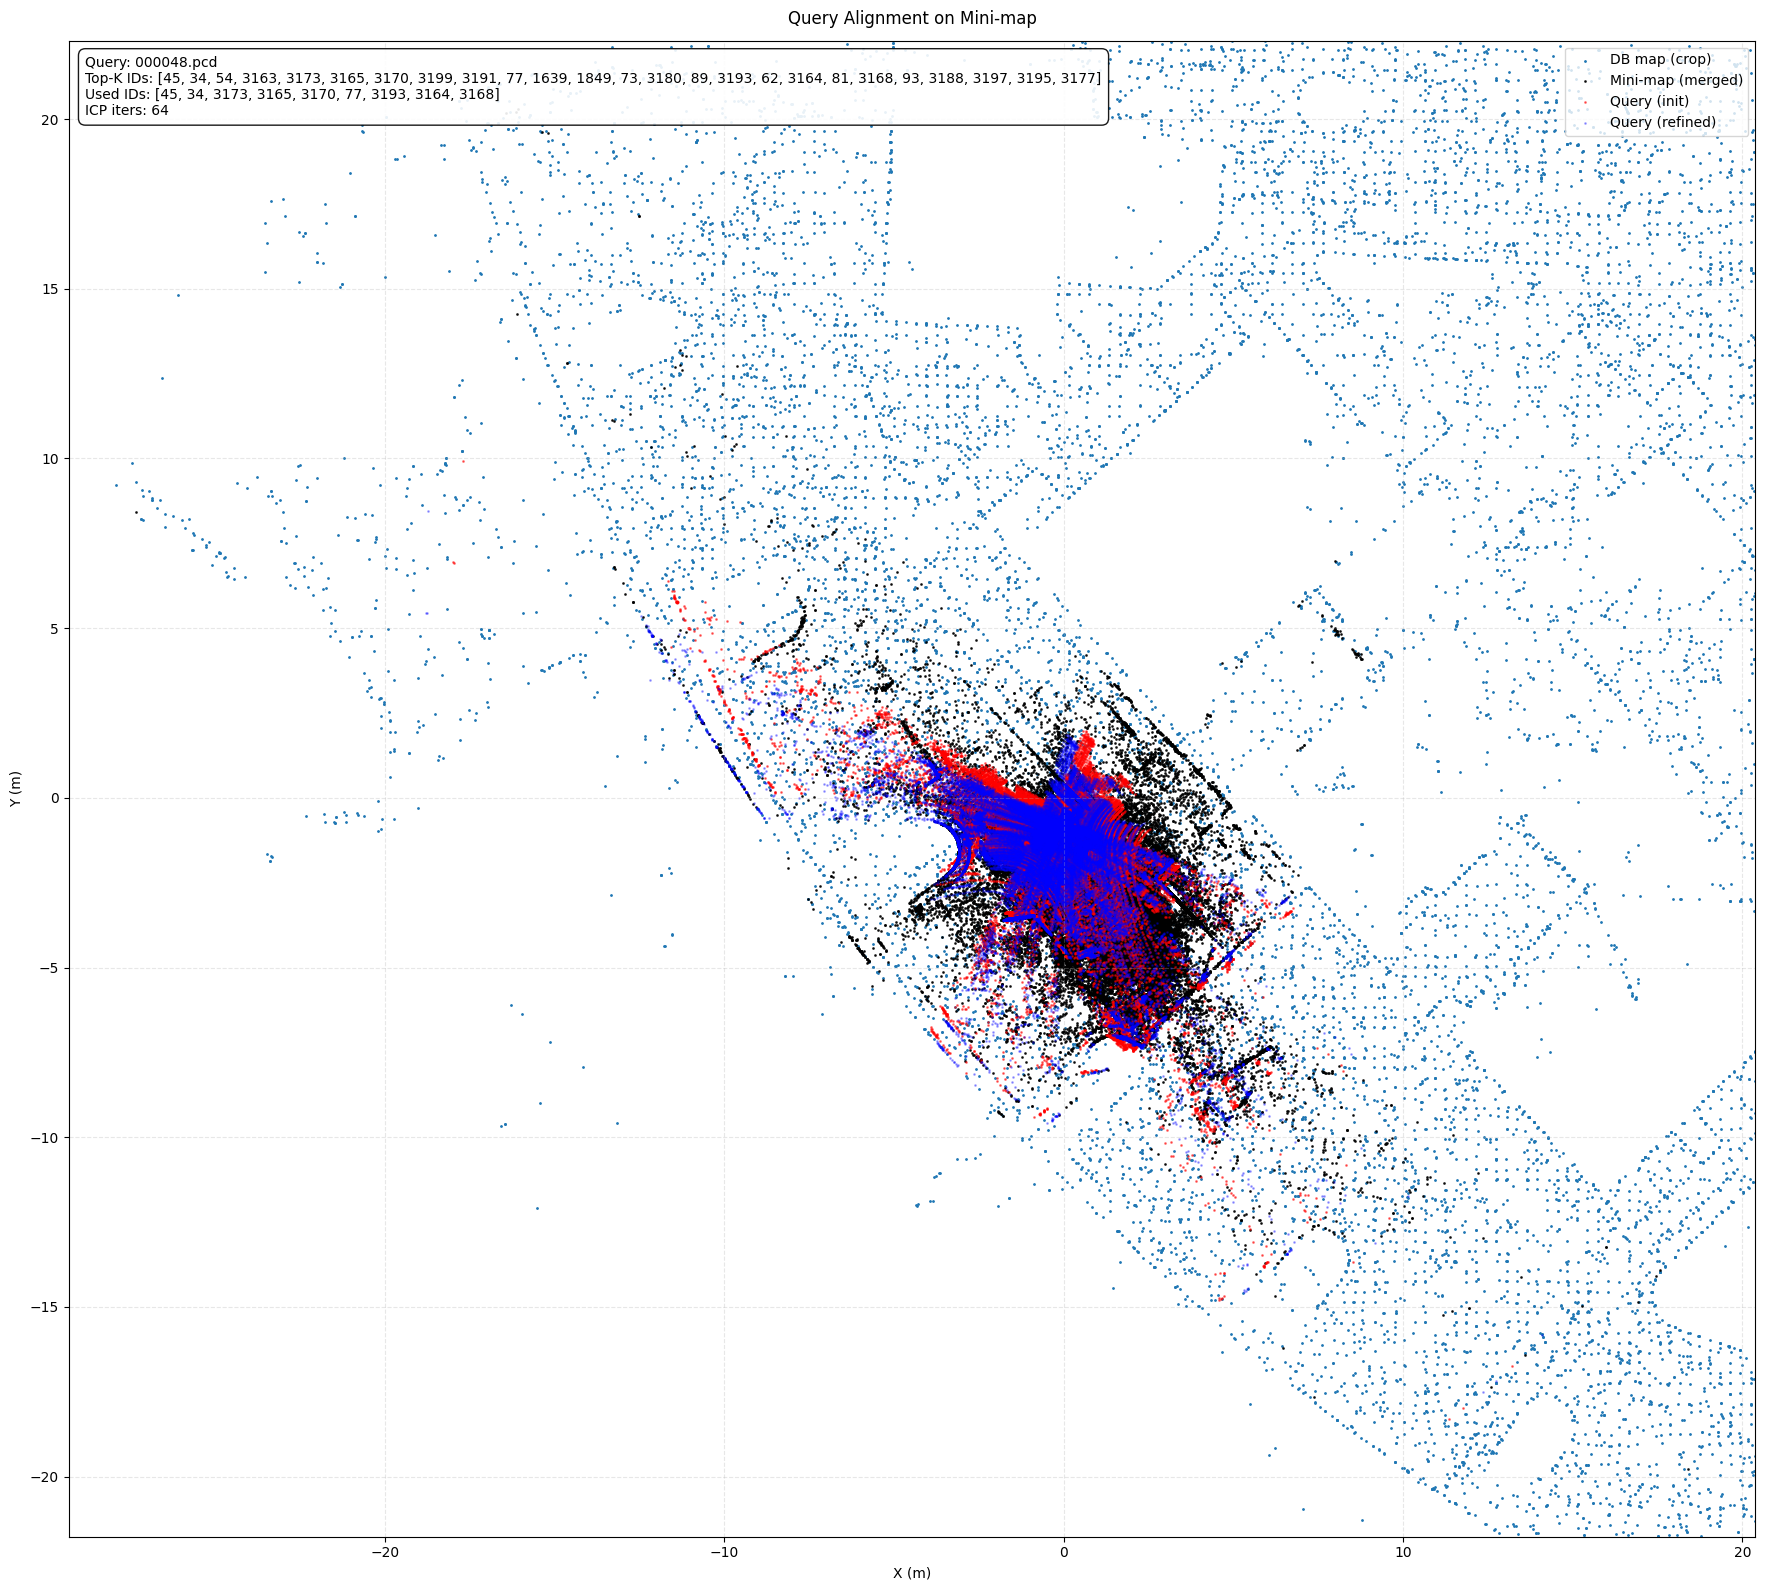

In [74]:

# === Parameters ===
K_NEIGHBORS   = 25                 # number of PR candidates
SELECTED_IDS  = None              # e.g., [ids_from_candidates[0], ids_from_candidates[2]]; None -> use all top-K
DOWNSAMPLE_DB = 0.2               # speed up visualization and mini‑map creation
MAX_ICP_ITERS = 64

# Load a voxelized reference map for context plotting
reference_metric_map_path = ROOT_DATA_DIR / "map1" / "metric_map" / "map_voxelized_0.3.pcd"
db_map_pcd = get_transformed_scan(reference_metric_map_path, ds_rate=DOWNSAMPLE_DB)


# Pick a random query id to run
QUERY_SCAN_ID = int(np.random.randint(0, 600))
query_scan_path = query_map_dir / "scans" / f"{QUERY_SCAN_ID:06d}.pcd"

print("Running place recognition + localization...")
localization_result = builder.infer_localization(
    pipeline=localization_pipeline,
    query_scan_path=query_scan_path,
    k=K_NEIGHBORS
)

# Gather candidates info
ids = []
gt_poses_on_db = []
estimated_poses_on_db = []
distances = []
for c in localization_result.candidates:
    ids.append(c.idx)
    gt_poses_on_db.append(c.db_pose)
    estimated_poses_on_db.append(c.estimated_pose)
    distances.append(c.pr_distance)

ids = list(ids)
gt_poses_on_db = Tf.from_quat(np.asarray(gt_poses_on_db)[:, 3:], np.asarray(gt_poses_on_db)[:, :3])
estimated_poses_on_db = Tf.from_quat(np.asarray(estimated_poses_on_db)[:, 3:], np.asarray(estimated_poses_on_db)[:, :3])

best_tf, inliers, outliers = outlier_rejector.estimate(estimated_poses_on_db)


SELECTED_IDS = [ids[i] for i in inliers]

if len(SELECTED_IDS) == 0:
    print("Outlier Rejection refused everything!")
    SELECTED_IDS = [ids[0]]
    best_tf = estimated_poses_on_db[0]



# Build mini‑map from selected ids (or all top‑K by default)
minimap_pts, used_ids = build_minimap_from_candidates(
    candidates=localization_result.candidates,
    selected_ids=SELECTED_IDS,
    root_dir=reference_map_dir,
    ds_rate=DOWNSAMPLE_DB
)
print("Mini‑map points:", minimap_pts.shape, "from IDs:", used_ids)

query_pts_init = get_transformed_scan(query_scan_path, tf=best_tf)

# Align query against mini‑map (refine pose)
result = align_query(pose_refinor, query_pts_init, minimap_pts)
print_pose_refinement_metadata(result)

correction = result.T_target_source

refined_pose = correction 
query_pts_ref = correction.apply(query_pts_init)

# Info overlay
info = f"Query: {QUERY_SCAN_ID:06d}.pcd\nTop-K IDs: {ids}\nUsed IDs: {used_ids}\nICP iters: {MAX_ICP_ITERS}"



# Plot
plot_alignment(db_map_pcd, minimap_pts, query_pts_init, query_pts_ref, info_text=info, bounds_margin=2.0)
